# Cache-Aware RAG Agent: Cutting Latency with `CachePolicy`



In this notebook you are going to build a **tool-using RAG (Retrieval-Augmented Generation) agent** with LangGraph, then cache its **tool calls (not the LLM)** with `CachePolicy(ttl=3600)` for measurable latency reduction on repeat queries. The LLM (Large Language Model) will pick between two tools: `faiss_lookup` against a local collection of information about the NASA Apollo-program Wikipedia articles, and `wikipedia_search` against the live Wikipedia API (Application Programming Interface). You will see repeat queries get faster without freezing the model's response.

**The core lesson:** Many times when running real agents, the slow, expensive operations are typically the tool calls, not the LLM. A `CachePolicy` is a LangGraph primitive that caches deterministic nodes by input, and the tools step is the natural place to attach it. We **deliberately do not cache the LLM** (the `agent` node) so that model regressions, prompt edits, and response tweaks stay visible.

**Architecture you'll build** (uncached baseline agent graph first, then split the tools step in two for the cached agent graph):

| Uncached baseline | Cached (split tools) |
|---|---|
| ![Uncached ReAct loop](images/ReAct_graph.png) | ![Cached graph with tools_fetch + tools_wrap](images/tool_call_graph.png) |
| `START → agent ⇄ tools → END` | `START → agent → tools_fetch → tools_wrap → agent → END` |

- `agent` node: `ChatOpenAI` with two tools bound. Decides which tool (if any) to call. **Not cached.**
- `tools` (uncached path) or `tools_fetch` + `tools_wrap` (cached path): execute the chosen tool. We split into two nodes in the cached version because a `ToolMessage`'s `tool_call_id` is regenerated by the LLM every turn. Caching the whole thing would replay stale IDs and OpenAI would reject the next agent step. `tools_fetch` is the cached half (content only). `tools_wrap` is the uncached half (attaches the current IDs).
- State: a `TypedDict` extending LangGraph's `MessagesState`, which uses `add_messages` to append (not whole-key replace like a plain `TypedDict`).

## Assumptions

You'll get the most out of this notebook if you have:

* Fundamentals of Generative AI and Large Language Models (LLMs)
* A high-level understanding of RAG architectures
* Familiarity with vector stores / vector databases
* Some hands-on experience with LangChain and LangGraph

Missing some of the above is fine. You can still follow along. The code is heavily commented for readers new to tool-using agents. If LangGraph specifically is new to you, skim the [LangGraph quickstart](https://langchain-ai.github.io/langgraph/) first. It'll give you a useful mental model for what follows.

## Tech Stack used in Notebook

* [LangChain](https://docs.langchain.com/oss/python/langchain/overview): Chat Agents
* [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview): Autonomous Agents
* [LangSmith](https://docs.smith.langchain.com/): Tracing & Observability (optional)
* [FAISS](https://github.com/facebookresearch/faiss): Vector Store
* [OpenAI model](https://developers.openai.com/api/docs): LLM
* [HuggingFace](https://huggingface.co/BAAI/bge-large-en-v1.5): Embedding Models
* [uv](https://docs.astral.sh/uv/): Python Dependency Management

> **LangSmith is optional, but I strongly recommend turning it on.** It gives visibility into each run the agent makes, the agent call flow, latency, tokens, and cost. The free personal tier is plenty for this notebook. You will see screenshots of LangSmith later in the notebook.

## Setup with uv (local users)

This repo uses [uv](https://docs.astral.sh/uv/), a fast Python package manager, to pin everything in `pyproject.toml` / `uv.lock`. If you cloned the repo locally you can run the below command in the cloned project directory:

```bash
uv sync
```

When running the notebook initially, select the project's `.venv` as the notebook kernel and skip the `%pip install` cell below if not running in Colab.



## Colab users setup

Colab users: uncomment the `%pip install` and run it once to install dependencies.

In [1]:
# Uncomment the pip install command if using Colab
# Colab-only install. Local repo users already have these pinned in pyproject.toml.

# %pip install -q "langgraph>=1.2.0" "langchain>=1.3.1" "langchain-core>=1.3.2" \
#   "langchain-openai>=1.2.1" "langchain-community>=0.4.1" \
#   "langchain-huggingface>=1.2.2" "langchain-text-splitters>=1.1.2" \
#   "sentence-transformers>=5.4.1" "faiss-cpu>=1.13.2" "wikipedia>=1.4.0" \
#   "pydantic>=2.0" "python-dotenv>=1.2.2" "langsmith>=0.8.5" "ipywidgets>=8.1.8" -q --no-warn-conflicts


## Environment Variable Setup

The cell below loads environment variables from a `.env` file at the repo root. See `.env.example` for the full list of supported variables.

* **`OPENAI_API_KEY`** (required): drives the `gpt-4o-mini-2024-07-18` agent (snapshot pinned via `LLM_MODEL`). Create one at [platform.openai.com](https://platform.openai.com/settings/organization/api-keys).
* **`LANGSMITH_API_KEY`** (optional, recommended): enables LangSmith tracing. Settings → API Keys at [smith.langchain.com](https://smith.langchain.com).
* **`HF_TOKEN`** (optional): only needed if you switch the embedding model to a gated HuggingFace model. The default BGE-large is public. Get one at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens).

In [2]:
# Env + imports for the whole notebook. LangSmith is optional - missing key falls back to local timing.
import getpass, json, os, time, wikipedia
from datetime import datetime, timezone
from difflib import SequenceMatcher

from dotenv import load_dotenv

from langchain_community.vectorstores import FAISS
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from typing_extensions import NotRequired

from langgraph.cache.memory import InMemoryCache
from langgraph.graph import END, MessagesState, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import CachePolicy

load_dotenv()

# look up a secret: first os.environ, then Colab's secrets store
def _resolve_key(name: str) -> str | None:
      if val := os.getenv(name):
          return val
      try:
          # only works inside Colab; ImportError elsewhere
          from google.colab import userdata  # noqa: E402  (Colab-only)
          return userdata.get(name)  # returns None if not set or not granted
      except Exception:
          # covers ImportError (not on Colab) and any userdata.get failure
          return None

# use the resolved key, or prompt for it if nothing was found
if key := _resolve_key("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = key
else:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

# Environment variables for observability
if key := _resolve_key("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = key
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    
    # New LangSmith project per notebook run so each execution shows up as
    # its own row on the Tracing page. Always overwrite (don't setdefault),
    # so a stale LANGSMITH_PROJECT in .env or a prior kernel can't pin
    # every run to the same project.
    run_stamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    os.environ["LANGSMITH_PROJECT"] = f"RAG Cache Policy {run_stamp}"
    print(f"LangSmith project: {os.environ['LANGSMITH_PROJECT']}")

# This is the OpenAI model that will be used by the agent
# You can update this to use any OpenAI model 
# https://developers.openai.com/api/docs/models/all
# Pinned snapshot so verification-cell timings/assertions stay reproducible.
# See README "Common gotchas" for rationale.
LLM_MODEL="gpt-4o-mini-2024-07-18"

# Simulated tool latency. Our local tools are sub-second so the cache speedup
# gets lost in LLM variance without this. Set to 0 to disable.
SIMULATED_TOOL_LATENCY_S = 2.0

LangSmith project: RAG Cache Policy 2026-05-28 03:59:43 UTC


## 1. Build (or load) the local Apollo knowledge base

In this section we build a small local knowledge base. We download about 20 Wikipedia pages on the Apollo program and store them in **FAISS (Facebook AI Similarity Search)**, a library that turns text into numeric vectors and searches them by similarity. Storing the pages this way lets the agent find relevant passages by meaning, not just by exact keyword matches.

The repo already ships a pre-built index in `faiss_store/`. If that folder is present (the default when you clone the repo) we just load it, which skips the slow build step. If it is missing (the Colab path, or after you delete it) we rebuild it from scratch. Either way, this index is the **`faiss_lookup` tool's backing store**: it is what that tool searches when the agent calls it. The live Wikipedia tool is separate and unrelated to this index.


In [3]:
from langchain_community.document_loaders import WikipediaLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Default: HuggingFace sentence transformer. BAAI/bge-large-en-v1.5 is a 1024-dim
# English model (~335M params) and the most-downloaded 1024-dim sentence
# transformer on the Hub. It runs locally - FREE to use locally, no API spend
# on embeddings.

# To switch to OpenAI embeddings, swap the HF block below for the OpenAI lines.
# Each backend uses its own folder (`faiss_store/` HF, `faiss_index/` OpenAI)
# because vector dims differ. The first switch rebuilds the index.
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-large-en-v1.5",
    encode_kwargs={"normalize_embeddings": True},
)
VECTOR_STORE_DIR = os.path.join(os.getcwd(), "faiss_store")

# Alternative: OpenAI text-embedding-3-small (1536-dim). Uncomment to use.
# embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
# VECTOR_STORE_DIR = os.path.join(os.getcwd(), "faiss_index")

# if vector store exist on disk we load
if os.path.isdir(VECTOR_STORE_DIR):
    vectorstore = FAISS.load_local(VECTOR_STORE_DIR, embeddings, allow_dangerous_deserialization=True)
    print(f"Loaded existing index from {VECTOR_STORE_DIR}")
else:
    # Build from scratch. ~20 pages, ~1-2 min locally with the HuggingFace (HF) embedding model (no API
    # spend), ~$0.02 with OpenAI embeddings. First HF run also downloads the
    # ~1.3 GB model weights to ~/.cache/huggingface/ (one-time).

    # add topics to a list
    TOPICS = [
        "Apollo program", "Apollo 1", "Apollo 7", "Apollo 8", "Apollo 9",
        "Apollo 10", "Apollo 11", "Apollo 12", "Apollo 13", "Apollo 14",
        "Apollo 15", "Apollo 16", "Apollo 17", "Saturn V", "Lunar Module",
        "Command and service module", "Project Mercury", "Project Gemini",
        "Neil Armstrong", "Buzz Aldrin",
    ]

    docs = []
    for topic in TOPICS:
        try:
            # retrieve wikipedia info about topic using the WikipediaLoader
            docs.extend(WikipediaLoader(query=topic, load_max_docs=1).load())
        except Exception as exc:
            print(f"skipped {topic}: {exc}")

    # breaks the retrieved text from wikipedia into chunks to be converted into vector embeddings
    splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
    chunks = splitter.split_documents(docs)

    # all topic chunks are written to the FAISS vector store
    vectorstore = FAISS.from_documents(chunks, embeddings)

    # FAISS already lives in memory after `from_documents`, save_local persists the
    # index to disk so a future kernel run can skip re-embedding (~1-2 min with HF,
    # ~$0.02 with OpenAI). 
    vectorstore.save_local(VECTOR_STORE_DIR)
    print(f"Built and saved index with {len(chunks)} chunks to {VECTOR_STORE_DIR}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loaded existing index from /Users/sheldonsides/Documents/Dev/AI/LinkedIn_AI/lang_graph_cache_rag_policy/src/faiss_store


## 2. Define the tools

In this section we define the tools that the agent has access to use.


A [LangGraph "tool"](https://docs.langchain.com/oss/python/langchain/tools) is simply a Python function decorated with `@tool` from `langchain_core.tools`. The decorator turns the function's docstring into the LLM's tool-selection prompt, so **docstring quality directly determines routing quality for agent**.

We give the agent two tools:

- **`faiss_lookup`**: Local Apollo articles. Fast (~100 ms cold, mostly the local embedding call).
- **`wikipedia_search`**: Live Wikipedia API. Slow (~500–2000 ms cold). This is the tool where caching gives the biggest visible win.

Both are deterministic enough to cache: the FAISS index is frozen on disk, and Wikipedia content changes slowly (usually over days), which is well within our `ttl=3600` (one hour) cache lifetime.

**A note on tool latency.** Real agent tools typically take 2–5 seconds per call. The notebook's tools are far cheaper on their own (`faiss_lookup` ~100 ms, `wikipedia_search` ~500–2000 ms), which would make the cache savings smaller than the LLM's run-to-run variance. To keep the lesson honest about cache value, the tool bodies below include a `time.sleep(SIMULATED_TOOL_LATENCY_S)` that defaults to 2 seconds. Only the simulated latency is added here; the caching itself works just like it would in production. Set `SIMULATED_TOOL_LATENCY_S = 0` at the top of the notebook to see the unsimulated elapsed times.

In [4]:
from requests.exceptions import RequestException

# Setting the USER_AGENT to Wikipedia reduces the odds of an aggressive rate-limit
# response. The wikipedia library defaults to a generic USER_AGENT that gets throttled.
wikipedia.set_user_agent(os.getenv("USER_AGENT", "langgraph-cachepolicy-rag-agent/1.0"))

@tool
def faiss_lookup(query: str) -> str:
    """Search the local Apollo-program Wikipedia articles for relevant passages.

    Use ONLY for questions about the NASA Apollo program (1961-1972), Apollo
    astronauts, the Apollo lunar landings, or related 1960s-70s American
    crewed spaceflight. Do NOT use for any other topic. Returns up to four
    short passages joined by separators.
    """
    # IMPORTANT: the docstring above is what the agent reads to decide
    # whether to call this tool. Keep it specific.

    # prints only when the tool really runs, so silence on the section 7 warm runs
    # confirms the cache skipped tools_fetch. Prefer the logging module in production.
    print(f"Tool used: faiss_lookup query={query!r}")

    # Simulated tool latency. See SIMULATED_TOOL_LATENCY_S at the top of the
    # notebook for the why. Sleeps after the print so the reader still sees
    # the tool fire on cold runs and the wait that follows.
    if SIMULATED_TOOL_LATENCY_S:
        time.sleep(SIMULATED_TOOL_LATENCY_S)

    # runs a similarity search and returns the top 4 matching documents
    # from the FAISS vector store
    docs = vectorstore.similarity_search(query, k=4)
    return "\n\n---\n\n".join(d.page_content for d in docs)

# private function called by the wikipedia_search tool
def _wikipedia_fetch(query: str) -> str:
    """Fetches a Wikipedia summary. Raises on temporary errors so the caller can retry."""
    try:
        # fetch the Wikipedia page, auto_suggest picks the closest match if
        # the query doesn't match exactly, and redirect follows article redirects.
        page = wikipedia.page(query, auto_suggest=True, redirect=True)
        return page.summary[:1500]
    except wikipedia.DisambiguationError as exc:
        page = wikipedia.page(exc.options[0], auto_suggest=False, redirect=True)
        return page.summary[:1500]


@tool
def wikipedia_search(query: str) -> str:
    """Fetch a Wikipedia article summary for the query.

    Use for general-knowledge questions, modern spaceflight (post-Apollo),
    or any topic NOT covered by `faiss_lookup`. Returns the first ~1500
    characters of the top-matching Wikipedia article summary.
    """
    # Side-effect print: same rationale as faiss_lookup. Placed here (not in
    # _wikipedia_fetch) so a transient-failure retry doesn't print twice.
    print(f"Tool used: wikipedia_search query={query!r}")

    # Simulated tool latency (see SIMULATED_TOOL_LATENCY_S at the top of the
    # notebook). Sleeps after the print so cold runs show the tool firing
    # then waiting. Warm runs bypass this function entirely.
    if SIMULATED_TOOL_LATENCY_S:
        time.sleep(SIMULATED_TOOL_LATENCY_S)

    # One retry with a small backoff covers transient Wikipedia API failures
    # (JSONDecodeError from a rate-limit HTML page, intermittent 5xx, etc.)
    # without doubling latency on the happy path.
    try:
        return _wikipedia_fetch(query)
    except wikipedia.PageError:
        return f"No Wikipedia article found for: {query}"
    except (RequestException, ValueError):
        # brief backoff before retry, giving a rate-limit or transient
        # network failure time to clear.
        time.sleep(1.0)
        try:
            return _wikipedia_fetch(query)
        except wikipedia.PageError:
            return f"No Wikipedia article found for: {query}"
        except (RequestException, ValueError) as exc:
            return f"Wikipedia request failed for {query!r}: {exc}"

# list of tools that will be bound to the LLM later via bind_tools()
TOOLS = [faiss_lookup, wikipedia_search]


## 3. The `agent` node (LLM with tools bound)

Here we walk through setting up the agent and the model it uses.

You can think of the agent node as the node that calls the LLM. The `bind_tools` function registers the two tools so the LLM can emit a `tool_calls` field on its response. `parallel_tool_calls=False` is needed for cache stability. With parallel calls enabled the LLM can emit `[faiss, wiki]` in either order across LLM call runs, which means the cache key changes between identical runs and we never get a cache hit.

We **do not cache** the agent node for the same reason we never cache the `generate` step in a classic RAG pipeline. Caching the model would freeze its response and hide quality changes when you switch to a newer model.

**Note on determinism:** `temperature=0` sets the sampler to the highest-probability token at every step, and `seed=LLM_SEED` is OpenAI's best-effort reproducibility knob: same seed + same `system_fingerprint` + same model attempts to return the same output. Together they minimize run-to-run variance, but the OpenAI API is **not perfectly reproducible**. Server-side batch routing and silent model updates can still shift wording slightly. That's exactly why the verification cell in section 11 uses a `SequenceMatcher` ratio of 0.6, not 1.0.

In [5]:
LLM_SEED = 42

# Build the tool-using LLM client: gpt-4o-mini-2024-07-18 (pinned) with the two @tool functions registered for routing.
llm_with_tools = ChatOpenAI(
    model=LLM_MODEL, temperature=0, seed=LLM_SEED
).bind_tools(TOOLS, parallel_tool_calls=False)

# defining the agent node
def agent(state: MessagesState) -> dict:
    """LLM step. NOT cached - we want every model change to be visible."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## 4. Wire the ReAct agent graph (uncached baseline)

Next we set up the entire agent graph flow.

LangGraph ships [`ToolNode`](https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph#step-4-build-your-nodes) (executes whichever tool the LLM picked) and `tools_condition` (the conditional edge that routes back to `tools` if there's a pending tool call, or to `END` otherwise). Wired together they give us the classic ReAct loop in a few lines.

The graph's **state** is the data passed from one node to the next. Ours is a `TypedDict` (a dictionary with fixed, named fields) built on top of LangGraph's `MessagesState`, so it already includes a `messages` list that holds the conversation. We also add one field of our own, `_tool_content`. The uncached graph never touches it, but defining it now lets the cached graph later slot in its two tool-handling nodes without us having to redefine the state.

One thing to know about the `messages` field: it uses the `add_messages` reducer. In plain terms, when a node returns `{"messages": [new_msg]}`, that message is *added* to the list instead of replacing it. That is how the agent keeps growing the conversation as the loop runs, turn after turn.


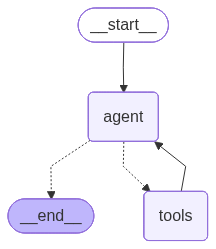

In [6]:
# this class holds the state of our agent
class AgentState(MessagesState): # -> https://reference.langchain.com/python/langgraph.prebuilt/chat_agent_executor/AgentState
    # Holds tool results between the cached fetch and wrap steps (see section 6).
    # NotRequired makes the key itself optional, so the uncached graph (which
    # never sets it) still type-checks.
    _tool_content: NotRequired[list[str] | None]


def build_uncached_agent():
    builder = StateGraph(AgentState) # What is a StateGraph -> https://docs.langchain.com/oss/python/langgraph/graph-api#stategraph

    # register the agent (LLM) node
    builder.add_node("agent", agent) # What is a node? -> https://docs.langchain.com/oss/python/langgraph/graph-api#nodes

    # register the tools node (LangGraph's prebuilt ToolNode runs whichever tool the LLM picked)
    builder.add_node("tools", ToolNode(TOOLS))

    # entry edge: the graph starts at the agent node
    builder.add_edge(START, "agent") # What is an edge -> https://docs.langchain.com/oss/python/langgraph/graph-api#edges

    # conditional edge: route to "tools" if the LLM emitted a tool_call, else to END
    builder.add_conditional_edges("agent", tools_condition) # What is a conditional edge -> https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges

    # loop back: after a tool runs, return to the agent so the LLM can read the result
    builder.add_edge("tools", "agent")

    return builder.compile() # Compiling a graph -> https://docs.langchain.com/oss/python/langgraph/graph-api#compiling-your-graph


# build and compile the uncached agent graph
agent_uncached = build_uncached_agent()

# will display the agent graph flow
agent_uncached

## 5. Run the baseline once
In this section we define a helper to run the uncached agent and get the agent graphs run time.

No caching means the LLM and whichever tool(s) the agent decides to use fire fresh, so this elapsed time is the baseline section 7 will be compared to.

The `QUESTION` asks about two distinct topics: NASA's Artemis program (modern, post-Apollo, which is not stored in the local FAISS store) and the Apollo program (with information stored in the local FAISS store from section 1). The agent's docstrings steer Apollo content to `faiss_lookup` and everything else to `wikipedia_search`, so under `parallel_tool_calls=False` the agent should fire one tool call for each topic, sequentially. You'll see one `[faiss_lookup] query=…` line and one `[wikipedia_search] query=…` line in the cell output below, and those are the cache entries section 7 will populate.


The `timed_invoke` helper below forwards optional `run_name` and `tags` into the `RunnableConfig`, so LangSmith labels each row by scenario (uncached baseline, cached cold, cached warm, verify, and so on) instead of the default `LangGraph`.

In [7]:
# Same question reused across uncached, cold, and warm runs so the cache hits
# actually hit and timings stay comparable. The prompt also asks about two
# distinct topics ("Artemis" and "Apollo"), so the agent fires two separate
# tool calls (wikipedia_search + faiss_lookup), giving us two cache entries
# to exercise in section 7.
QUESTION = (
    "Tell me about the NASA's Artemis program and tell me about the Apollo program."
)

# helper function that invokes the agent graph and times the call
def timed_invoke(graph, payload, run_name=None, tags=None):
    """Time `graph.invoke` and forward `run_name`/`tags` into LangSmith's
    `RunnableConfig` so each row is labeled by scenario (see section 7)."""
    config = {}

    # attach LangSmith trace labels (run_name + tags) -> https://docs.langchain.com/langsmith/trace-with-langchain#add-metadata-and-tags-to-traces
    if run_name:
        config["run_name"] = run_name
    if tags:
        config["tags"] = tags

    start = time.perf_counter()

    # actually invokes the agent graph
    result = graph.invoke(payload, config=config or None)
    
    return result, time.perf_counter() - start


# return the agent's final answer from the graph result
def final_answer(result):
    """Walk the message history newest-first and return the last AIMessage
    that is NOT a tool-call request (i.e. the agent's final reply)."""

    # walk messages newest-first so the final answer is the first hit
    for msg in reversed(result["messages"]):
        # keep AIMessages that are real replies, skip ones that are tool-call requests
        if isinstance(msg, AIMessage) and not msg.tool_calls:
            return msg.content

    # no final answer found (agent errored out), return "" instead of None
    return ""


# input payload: MessagesState expects a {"messages": [...]} dict, so wrap QUESTION in a HumanMessage
payload = {"messages": [HumanMessage(content=QUESTION)]}

# run the uncached agent once. The result + elapsed time become the baseline section 7 compares against
uncached_result, uncached_latency_s = timed_invoke(
    agent_uncached, payload, run_name="uncached-agent-run", tags=["uncached"]
)

print(f"Uncached run: {uncached_latency_s:.2f}s")
print(f"\nAgent answer (first 1000 chars):\n{final_answer(uncached_result)[:1000]}")

Tool used: wikipedia_search query='NASA Artemis program'
Tool used: faiss_lookup query='Apollo program'
Uncached run: 18.73s

Agent answer (first 1000 chars):
### NASA's Artemis Program
The Artemis program is a Moon exploration initiative led by NASA, aimed at returning humans to the Moon for the first time since the Apollo program and establishing a permanent lunar base. It was formally established in 2017 through Space Policy Directive-1 by President Donald Trump. Key components of the Artemis program include:

- **Space Launch System (SLS)**: A powerful rocket designed to carry astronauts and cargo to the Moon.
- **Orion Spacecraft**: A crewed spacecraft that will transport astronauts to lunar orbit and back.
- **Human Landing System (HLS)**: A lunar lander being developed by private companies to facilitate landings on the Moon's surface.

The program has several planned missions:
- **Artemis I**: An uncrewed mission that successfully sent the Orion spacecraft to lunar orbit in 2022

## 6. Add `CachePolicy`, but split the tools step in two

Next we walk through how to configure `CachePolicy` on an agent graph.

There's a subtle gotcha attaching `CachePolicy` directly to `ToolNode`: a `ToolMessage` carries the `tool_call_id` of the AIMessage that triggered it, and that id is **regenerated by the LLM on every invocation**. If we cache the entire `ToolNode` output verbatim and replay it on the next run, the cached `ToolMessage` carries a *stale* id that doesn't match the LLM's new `tool_calls`, and OpenAI rejects the next agent step with a 400 error.

We fix by splitting the tools step into two nodes:

1. **`tools_fetch`** (cached): runs `ToolNode` internally and extracts just the **content strings**. No tool_call_id leakage, so the cached value is safe to reuse.
2. **`tools_wrap`** (uncached): builds fresh `ToolMessage` objects, attaching the **current** AIMessage's tool_call_ids onto the cached content.

This keeps `CachePolicy` exactly where we want it (on the deterministic boundary) and quarantines the ID-rewriting in a small, never-cached step.

A few things to notice:
- The `key_func` builds the cache key from just the current pending tool call (its name and arguments), not the full conversation history. That way, repeating the same tool call hits the cache even after the chat has grown.
- `CachePolicy(ttl=3600, ...)` gives us a one-hour TTL (Time To Live) on cached tool outputs. Wikipedia content is stable for hours, so this is generous but safe.
- The graph compiles with `InMemoryCache()` so the cache has a backing store.

The `agent` node and the tools themselves stay unchanged.

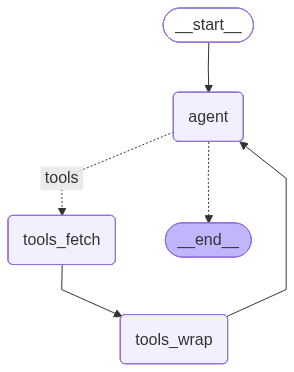

In [8]:
_inner_tools = ToolNode(TOOLS)

# CachePolicy time-to-live in seconds (1 hour). See the markdown above for why
CACHE_TTL_S = 3600


# cached fetch step: runs the real tool and returns just its content (no live IDs)
def tools_fetch(state: AgentState) -> dict:
    """Cacheable boundary: same (name, args) yields the same content. Runs
    ToolNode internally and strips out the live tool_call_ids."""

    # run the LLM-chosen tool via ToolNode, `inner` is a dict containing fresh ToolMessage objects
    inner = _inner_tools.invoke(state)

    # cache ONLY the content strings, not the ToolMessages (those carry live tool_call_ids)
    return {"_tool_content": [m.content for m in inner["messages"]]}


# uncached wrap step: attaches live tool_call_ids onto the cached content
def tools_wrap(state: AgentState) -> dict:
    """Attaches the CURRENT AIMessage's tool_call_ids onto the cached content
    so the next agent step sees ToolMessages whose IDs match its pending
    tool_calls. NEVER cached."""

    # this is the tool_calls the LLM just emitted. OpenAI regenerates these IDs every turn
    calls = state["messages"][-1].tool_calls

    # pair each cached content string with its matching live tool_call_id and rebuild a ToolMessage
    return {
        "messages": [
            ToolMessage(content=content, tool_call_id=call["id"], name=call["name"]) # -> https://reference.langchain.com/python/langchain-core/messages/tool/ToolMessage
            for content, call in zip(state["_tool_content"], calls)
        ],

        # reset `_tool_content` so a stale value can't leak into the next turn
        "_tool_content": None,
    }


# CachePolicy key_func: hash on (tool name, args), not the full conversation history
def tool_call_key(state: dict) -> str:
    # state.get fallback in case LangGraph inspects the graph before any input arrives
    messages = state.get("messages") or []

    # empty state, return a placeholder string. Shouldn't fire at runtime
    if not messages:
        return "__no_messages__"

    # the most recent message should be the LLM's reply carrying `tool_calls`
    last = messages[-1]

    # sanity check: needs to be an AIMessage with at least one pending tool call
    if not isinstance(last, AIMessage) or not last.tool_calls:
        return "__no_pending_tool_calls__"

    # one (name, sorted-args-JSON) tuple per call, sort_keys=True keeps the key stable across dict orderings
    norm = [(c["name"], json.dumps(c["args"], sort_keys=True)) for c in last.tool_calls]

    # the JSON-serialized list IS the cache key
    return json.dumps(norm)


# wire up the cached variant of the graph (CachePolicy attached to tools_fetch only)
def build_cached_agent():
    # graph builder, same AgentState schema as the uncached version (section 4)
    builder = StateGraph(AgentState)
    
    builder.add_node("agent", agent)

    # cached tool-execution node. CachePolicy attaches HERE (and only here)
    # this is how tool caching is enabled on the agent graph
    builder.add_node(
        "tools_fetch",
        tools_fetch,
        cache_policy=CachePolicy(ttl=CACHE_TTL_S, key_func=tool_call_key),
    )

    # uncached wrapper that adds live tool_call_ids to the cached content
    builder.add_node("tools_wrap", tools_wrap)

    # entry edge: graph starts at the agent node
    builder.add_edge(START, "agent")

    # conditional edge: if the LLM asked for a tool, route to tools_fetch, else go to END
    builder.add_conditional_edges(
        "agent", tools_condition, {"tools": "tools_fetch", END: END}
    )

    # fetch -> wrap is unconditional (always rewrap before the next LLM step)
    builder.add_edge("tools_fetch", "tools_wrap")

    # wrap -> agent closes the ReAct loop so the LLM can read the tool result
    builder.add_edge("tools_wrap", "agent")

    # compile with an in-process cache. It lives only as long as this Python kernel,
    # so restarting the notebook kernel wipes the cache
    return builder.compile(cache=InMemoryCache())

# build and compile the cached agent graph
agent_cached = build_cached_agent()

# display the cached agent graph
agent_cached

> **Lifetime callout.** `InMemoryCache` lives only for the kernel's lifetime. Notebook **Kernel restart = cache gone.** For cross-session persistence you'd swap in a Redis or SQLite-backed cache. The rest of the graph code is unchanged.


## 7. Run the cached agent and measure the difference

In this section we run the same question three times against the cached agent and measure the speed increase the cache buys us.

Run 1 is **cold**: the cache is empty, so the `(tool_name, args)` lookup misses. The tools fire live and their results are *written* to the cache under those keys. Run 1 pays full price (including the simulated 2-second latency per tool from section 2) specifically to populate the cache for the warm runs that follow.

Runs 2 and 3 are **warm** (cached): the same `(tool, args)` pairs are looked up, hit, and `tools_fetch` is bypassed without running the tool functions. That's why you'll see a `[…]` print per tool call on run 1 and *zero* prints on runs 2 and 3. Run 3 is there to confirm the cache stays populated.

We average the two warm runs and report the ratio against the uncached baseline. Single-run speedup numbers vary with LLM and network noise, so focus on the two-run average.

The LLM still runs every time (we don't cache it), so the speedup is limited by the LLM's latency. With two tool calls at a simulated 2 seconds each, the cache should save about 4 seconds on every warm run, pushing the ratio comfortably above `1.0x`.

In [9]:
# `run_name` and `tags` are `RunnableConfig` keys LangSmith reads when
# the trace is shipped: `run_name` becomes the row title (instead of the
# default `LangGraph`), `tags` are facet filters in the UI. Labeling
# only - the graph and the cache behave identically with or without them.
# you will see this in section -> 8. What this looks like in LangSmith

# We are running the new agent graph using the cache policy
# so the first call below will not hit the cache (the cache is empty).
# The tools actually run and their results are saved to the cache so
# the warm runs below can reuse them.
cold_run_result, cold_run_latency_s = timed_invoke(
    agent_cached, payload, run_name="cached-agent-run-1", tags=["cached", "cold"]
)   # cold: cache empty, tools fire live, results stashed under (tool, args) keys


warm_run_1_result, warm_run_1_latency_s = timed_invoke(
    agent_cached, payload, run_name="cached-agent-run-2", tags=["cached", "warm"]
)   # warm: same (tool, args) keys hit, tools_fetch is bypassed

warm_run_2_result, warm_run_2_latency_s = timed_invoke(
    agent_cached, payload, run_name="cached-agent-run-3", tags=["cached", "warm"]
)   # warm: a second hit, confirming the cache stays hot

print(f"cold run (priming): {cold_run_latency_s:.2f}s")
print(f"warm run 1:         {warm_run_1_latency_s:.2f}s")
print(f"warm run 2:         {warm_run_2_latency_s:.2f}s")

# Average the two warm runs and compare to the single uncached baseline from
# section 5. Averaging smooths the per-run OpenAI/network variance so the
# speedup ratio reads as the headline number, not a single-shot variation. The
# cold run is excluded on purpose, it's the priming cost, not a cached path.
avg_warm_latency_s = (warm_run_1_latency_s + warm_run_2_latency_s) / 2
print(
    f"\naverage warm run: {avg_warm_latency_s:.2f}s"
    f"  |  average speedup vs uncached: {uncached_latency_s / max(avg_warm_latency_s, 1e-6):.2f}x"
)

# SequenceMatcher.ratio() returns a 0.0-1.0 similarity score between two
# strings (1.0 == identical). We compare the uncached and cached final
# answers to confirm caching only sped things up, it didn't change what
# the agent said. We expect a high but not perfect score: temperature=0
# plus seed=LLM_SEED minimize drift, but the OpenAI API isn't perfectly
# reproducible, so wording can vary slightly between runs.
answer_similarity = SequenceMatcher(
    None, final_answer(uncached_result), final_answer(warm_run_1_result)
).ratio()

print(f"answer similarity (uncached vs cached): {answer_similarity:.2f}")
print(f"\nFinal answer (warm run 1):\n{final_answer(warm_run_1_result)[:400]}...")

Tool used: wikipedia_search query='NASA Artemis program'
Tool used: faiss_lookup query='Apollo program'
cold run (priming): 21.78s
warm run 1:         11.47s
warm run 2:         10.97s

average warm run: 11.22s  |  average speedup vs uncached: 1.67x
answer similarity (uncached vs cached): 0.87

Final answer (warm run 1):
### NASA's Artemis Program

The Artemis program is a Moon exploration initiative led by NASA, aimed at returning humans to the Moon for the first time since the Apollo program and establishing a permanent lunar base. It was formally established in 2017 through Space Policy Directive-1 by President Donald Trump. Key components of the Artemis program include:

- **Space Launch System (SLS)**: A powe...


## 8. What this looks like in LangSmith

If you set `LANGSMITH_API_KEY` earlier, the env-setup cell created a project named like `RAG Cache Policy <datetime>`. Open it in https://smith.langchain.com and you'll see one row per timed agent call. In this example I'm using LangSmith, my preferred agent observability and tracing platform.

Observability is key when building agents and understanding where latency and performance issues may exist. LangSmith shows exactly what each agent did, along with latency, token usage, cost, and other telemetry tied to the agent graph. 

The screenshot below was captured right after section 7, so it shows just those four runs (the uncached baseline plus the cold and two warm cached runs). Running sections 9 and 10 as well would add more rows to the same project.

**Note:** The latency you see in LangSmith will vary with response times from your LLM provider and from any API-based tools the agent calls (Wikipedia here).

[![LangSmith project page listing the four timed runs of section 7](images/lang_smith_project_run.png)](images/lang_smith_project_run.png)

Drilling into each row gives the waterfall. Four traces in execution order, reading left to right across the top row, then the bottom (click any image to view full size):

| **1. Uncached baseline agent (~13.2s)** | **2. Cached, cold priming (~12.2s)** |
|---|---|
| [![Uncached waterfall](images/uncached_run.png)](images/uncached_run.png) | [![Cold priming cached waterfall](images/priming_cache_run.png)](images/priming_cache_run.png) |
| This is the baseline agent, with no caching. It thinks, calls a tool, thinks again, then calls a second tool. The `tools` node runs twice: once for `wikipedia_search` (3.16s) and once for `faiss_lookup` (2.17s). The `agent` (the LLM) runs three times. The last `agent` run (6.25s) writes the final answer and takes the most time. | Now we run the cached agent for the first time, so the cache is still empty. The old `tools` node is now two steps: `tools_fetch` (the part we cache) and `tools_wrap` (the part we don't). Because nothing is saved yet, `tools_fetch` still does the real work (2.54s and 2.08s). So this run is about as slow as the baseline uncached agent. |
| **3. Cached, warm run 1 (~7.2s)** | **4. Cached, warm run 2 (~7.5s)** |
| [![Warm cached run 1, tools_fetch absent](images/cached_run_1.png)](images/cached_run_1.png) | [![Warm cached run 2, tools_fetch absent](images/cached_run_2.png)](images/cached_run_2.png) |
| We run the cached agent again, and this time the cache already has the answers. Notice that `tools_fetch` is gone from the image above: the cache returned its result right away, so there is no call to any tools. Only `tools_wrap` (0.00s) and the three `agent` runs are left. The run dropped from about 12s to about 7s, we saved time because the tool calls were skipped. | We run the cached agent one last time. It looks just like the run before, with `tools_fetch` still gone, which shows the cache is still working on a second run of the agent. Almost all the time left is the last `agent` run (6.51s). That is the model thinking, and the cache cannot speed that up. It is the fastest this agent can run. |

## 9. Cache misses: change the inputs, to skip the cache

In this section we'll force a cache miss by changing the inputs.

Remember caches aren't magic. They key on inputs. Our `tool_call_key` hashes on the tool name and its args. So any change in the args (for example, the LLM rephrases an existing query, or makes a fresh tool call for a new topic) produces a different cache key and forces the tool node to re-run in the agent graph.

Below we extend the user question with a third ask that the existing two tool calls don't cover. The LLM should fire a fresh `wikipedia_search` for the new topic, giving us a new cache key and a miss. The original two cached entries (the Apollo-program lookup and the Artemis description) stay put, so the rest of the warm path can still hit the cache, as long as the LLM reissues the same query args.


In [10]:
# new question text. The different wording forces different tool-call args, so the cache key won't match
rephrased = (
    QUESTION
    + " briefly describe the Saturn V program."
)

# wrap the question in a human message the agent expects
miss_payload = {"messages": [HumanMessage(content=rephrased)]}

# run the cached agent on the new question. Expect a cache miss, so you should see similar timing of cold run
_, cache_miss_latency_s = timed_invoke(
    agent_cached, miss_payload, run_name="cache-miss", tags=["cached", "miss"]
)

print(f"cache-miss invocation: {cache_miss_latency_s:.2f}s  (likely close to the cold run above)")

Tool used: faiss_lookup query='Saturn V program'
cache-miss invocation: 16.94s  (likely close to the cold run above)


## 10. Why this design works and takeaways

- **Cache tool calls, not the LLM.** Tool outputs are a deterministic function of `(tool_name, args)`, so they're safe to cache (we attach `CachePolicy` to the `tools_fetch` node). The LLM isn't deterministic, so it stays outside the cache.
- **Keep live IDs out of the cached value.** `ToolMessage.tool_call_id` is regenerated by the LLM every turn. If you cache the wrapped ToolMessage you'll replay a stale id and the next LLM call will give you a 400 error. Splitting fetch (cached, content only) from wrap (uncached, attaches current ids) is the recommended way to keep `CachePolicy` clean.
- **`key_func` is what makes the cache useful in the agent graph.** The default cache key includes the full state (i.e., the whole message history). Without a `key_func`, every new conversation produces a different key and you would never get cache hits. Hashing only on the pending tool call's `(name, args)` is what lets repeated tool calls, within or across conversations, actually share results.
- **The cache key discriminates per `(tool_name, args)`.** Because `key_func` hashes both, `faiss_lookup` and `wikipedia_search` get separate cache entries even when called in the same run, and the same tool gets a separate entry for every distinct argument value. Section 7's warm pass hits both entries. Neither evicts the other.
- **TTL matches data drift, not run frequency.** We use `ttl=3600` because Wikipedia summaries are stable for hours. If you cache a tool that talks to a fast-moving source (a stock price API, a CI status endpoint), drop the TTL value accordingly.
- **`parallel_tool_calls=False` is a cache-stability requirement, not a style choice.** Order-sensitive cache keys are the easiest way to silently destroy your cache hit rate.
- **Speedup magnitude depends on the tool/LLM ratio.** With `gpt-4o-mini` and our two real (fast) tools, the LLM dominates elapsed time and the cache savings disappear into per-call variance. This notebook simulates 2 seconds of tool latency per call (`SIMULATED_TOOL_LATENCY_S` at the top) so the warm-run speedup is visible. Set it to `0` and you'll see the ratio collapse back to roughly `1.0x`. In production, slow tools (multi-second HTTP APIs, expensive vector searches, paid third-party services) make the savings compound and the ratio grows. The cache mechanism is identical either way.

That's it. A small `CachePolicy` block, a `key_func`, and a two-node split for the tools step, and the agent caches its slow operations without ever freezing the model's behavior. Same trick works for any LangGraph node whose I/O you can reason about deterministically.


## 11. Verify the cache

Run the cell below to check that the cache is functioning as expected. It times an uncached run against cached runs and fails if caching makes the agent graph slower.

A self-contained sanity check the notebook can use to assert its own headline. We compare a timed uncached run against the median of three timed cached runs, fail if the cached path is materially slower than uncached, and confirm the two answers stay in the same ballpark via `SequenceMatcher`.

In [ ]:
import statistics

# LLM dominates total time and adds variance on the order of hundreds of ms per
# call. We only fail if cached is clearly slower than uncached, not on every
# sub-second variation.
NOISE_MARGIN_S = 1.0

def _final_answer(result):
    # Walk messages in reverse and return the last AIMessage with no pending
    # tool_calls. That's the agent's final natural-language response.
    for msg in reversed(result["messages"]):
        if isinstance(msg, AIMessage) and not msg.tool_calls:
            return msg.content
    return ""


# Reuse the agent builders defined earlier in the notebook (sections 4 and 6).
verify_uncached = build_uncached_agent()
verify_cached = build_cached_agent()

# Rebuild the payload locally in case earlier cells mutated it.
verify_payload = {"messages": [HumanMessage(content=QUESTION)]}

# Warm-up uncached to absorb first-call OpenAI / Wikipedia skew. The timed
# invocation is the second call.
_ = verify_uncached.invoke(
    verify_payload,
    config={"run_name": "verify-uncached-warmup", "tags": ["verify", "warmup"]},
)

verify_uncached_result, verify_uncached_latency_s = timed_invoke(
    verify_uncached,
    verify_payload,
    run_name="verify-uncached",
    tags=["verify", "uncached"],
)

verify_uncached_answer = _final_answer(verify_uncached_result)

# Prime the cached graph, then take the median of three timed warm runs to
# smooth LLM/network variance.
_ = verify_cached.invoke(
    verify_payload,
    config={"run_name": "verify-cached-prime", "tags": ["verify", "prime"]},
)

verify_cached_latencies_s = []
verify_cached_result = None

for i in range(3):
    verify_cached_result, run_latency_s = timed_invoke(
        verify_cached,
        verify_payload,
        run_name=f"verify-cached-warm-{i+1}",
        tags=["verify", "cached"],
    )
    verify_cached_latencies_s.append(run_latency_s)

verify_cached_median_latency_s = statistics.median(verify_cached_latencies_s)
verify_cached_answer = _final_answer(verify_cached_result or {"messages": []})

speedup_ratio = verify_uncached_latency_s / max(verify_cached_median_latency_s, 1e-6)
answer_similarity = SequenceMatcher(None, verify_uncached_answer, verify_cached_answer).ratio()

assert verify_cached_median_latency_s <= verify_uncached_latency_s + NOISE_MARGIN_S, (
    f"Cached path is materially slower than uncached: "
    f"cached_median={verify_cached_median_latency_s:.2f}s vs "
    f"uncached={verify_uncached_latency_s:.2f}s (margin={NOISE_MARGIN_S}s). "
    f"Check parallel_tool_calls=False, the custom key_func on tools_fetch, "
    f"and that the agent (LLM) node is NOT cached."
)

assert answer_similarity >= 0.6, (
    f"Cached and uncached answers diverged beyond tolerance: "
    f"answer_similarity={answer_similarity:.2f}. LLM nondeterminism can shift "
    f"wording at temperature=0; re-run before assuming a real regression."
)

print(
    f"PASS: cache speedup {speedup_ratio:.2f}x "
    f"(uncached={verify_uncached_latency_s:.2f}s vs "
    f"cached_median={verify_cached_median_latency_s:.2f}s), "
    f"answer similarity={answer_similarity:.2f}"
)


## 12. Where to go from here

You have the full pattern working. A few directions to take it next:

- **Make the cache outlive the kernel.** `InMemoryCache` is process-local, which is why restarting the kernel clears it. For a real service, back `CachePolicy` with a persistent, shared store (the SQLite- or Redis-backed caches mentioned in section 6) so hits survive restarts and span worker processes.
- **Cache beyond `ToolNode`.** `CachePolicy` attaches to any node, so the same fetch/wrap discipline carries over to other expensive, deterministic steps you build later: a retrieval node, an embedding call, a paid third-party API wrapper.
- **Profile your own tool/LLM ratio first.** Set `SIMULATED_TOOL_LATENCY_S = 0` to see your tools' real cost. If they are genuinely fast, caching may not earn its complexity. Spend it on the steps that are actually slow or paid.
- **Persist the conversation separately.** Node caching speeds repeated work. It does not remember chat history. For multi-turn memory across sessions, add a checkpointer, which is a different LangGraph primitive aimed at state persistence rather than node reuse.